In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../../data/fuel_consumption.csv")

In [4]:
df.head()

,Speed,Fuel_Consumption
0,10,8
1,20,10
2,30,15
3,40,22
4,50,31


In [6]:
df.describe()

,Speed,Fuel_Consumption
count,10.000000,10.0000
mean,55.000000,44.6000
std,30.276504,34.0529
min,10.000000,8.0000
25%,32.500000,16.7500
50%,55.000000,36.5000
75%,77.500000,66.2500
max,100.000000,106.0000


In [7]:
x = df[["Speed"]]
y = df[["Fuel_Consumption"]]

In [11]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [12]:
model = LinearRegression()

In [13]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[1.09]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Speed']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-16.45]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [14]:
print("Coefficient: " , model.coef_[0])

Coefficient:  [1.09224138]


In [15]:
print("Interception :" , model.intercept_)

Interception : [-16.44827586]


In [16]:
y_prediction = model.predict(x_test)

In [21]:
y_prediction

array([[81.85344828],
       [ 5.39655172]])

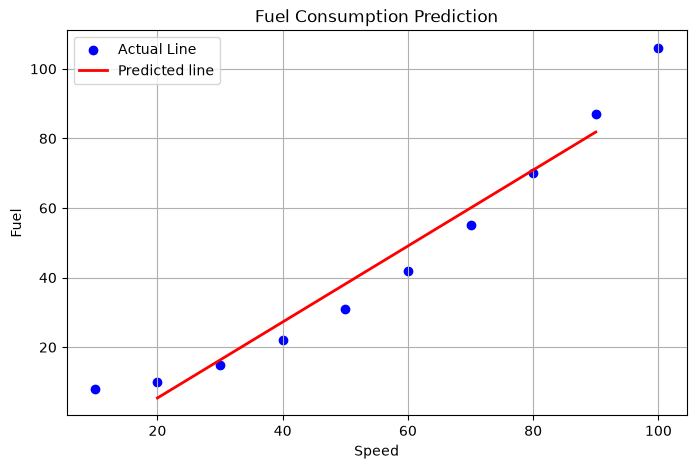

In [20]:
plt.figure(figsize=(8,5))
plt.scatter(x,y,color='blue',label='Actual Line')
plt.plot(x_test,y_prediction,color='red',linewidth="2",label='Predicted line')
plt.title("Fuel Consumption Prediction")
plt.xlabel("Speed")
plt.ylabel("Fuel")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
from sklearn.preprocessing import PolynomialFeatures

In [23]:
poly = PolynomialFeatures(degree=2)
x_poly = poly.fit_transform(x) 

In [24]:
print(x_poly[:3])

[[  1.  10. 100.]
 [  1.  20. 400.]
 [  1.  30. 900.]]


In [25]:
poly_model = LinearRegression()
poly_model.fit(x_poly,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 3)","[[ 0. ,-0.03, 0.01]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[6.9]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[10252.46, 20.36, 0. ]"


# Draw the polynormal curve

In [26]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_prediction)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 4.8749999999999964


In [ ]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_prediction)
print("R^2 score:", r2)


R^2 score: 0.983916771571002


/media/dilan/New Volume/IJSE/4 Sem/ML/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


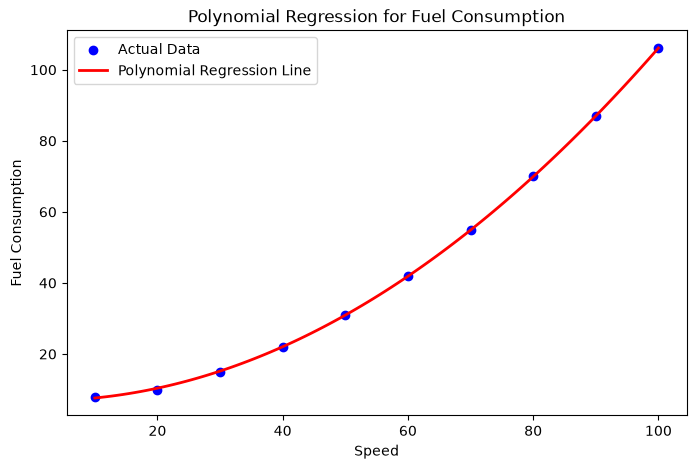

In [31]:
x_grid = np.linspace(x.min(), x.max(), 100)
x_grid = x_grid.reshape(-1, 1)
x_grid_poly = poly.transform(x_grid)
y_grid = poly_model.predict(x_grid_poly)
plt.figure(figsize=(8,5))
plt.scatter(x, y, color='blue', label='Actual Data')
plt.plot(x_grid, y_grid, color='red', linewidth=2, label='Polynomial Regression Line')
plt.xlabel("Speed")
plt.ylabel("Fuel Consumption")
plt.title("Polynomial Regression for Fuel Consumption")
plt.legend()


In [30]:

speed = np.array([[75]])
speed_poly = poly.transform(speed)
print("Speed_poly")
print("Prediction:", poly_model.predict(speed_poly))

Speed_poly
Prediction: [[62.14431818]]


/media/dilan/New Volume/IJSE/4 Sem/ML/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
